## Overall Structure
We begin by creating a population matrix for each ethnicity and gender combination, where:

Each row represents a unique agent (individual).

Each column represents a calendar year.

The time span is divided into two :

Retrospective years (1990–2023) for historical analysis.

Projection years (2024–2050) for future forecasting.

and therefore we will have two set of matrices, for this file, we only show matrices of retrospective years `age_matrix_vec`

The values in the matrix represent the age of each agent in a given year:

A value of -1 indicates that the agent is either not yet born or has already died in that year.


## Disease Mapping
Once the population matrix is established, we perform matrix mapping using disease-specific transition rates to simulate health outcomes. This results in corresponding disease state matrices.

Examples:
Diabetes Matrices `diabetes_mat_list`

Values:

0 = Healthy

0.5 = Pre-diabetes

1 = Diabetes

Hypertension Matrices `hyper_mat_list`

Values:

0 = Healthy

1 = Hypertension



In this case, that we don't use struct but use matrix directly. 

Through it may be hard to read and understand, but it's faster for the matrix operations. 

In [49]:
import os
import numpy as np
import pandas as pd

# List to store the NumPy arrays (equivalent to std::vector<ArrayXXi> in C++)
age_matrix_vec_2050 = []

# Directory containing the binary files
data_dir = "../../output/20250526_151118"

# Read each binary file
for i in range(8):
    filename = os.path.join(data_dir, f"forecast_matrix_{i}.bin")
    
    # Get file size to determine number of rows
    file_size = os.path.getsize(filename)
    num_rows = file_size // (27 * 4)  # 27 columns, 4 bytes per int32
    
    # Create numpy matrix of appropriate size
    matrix = np.zeros((num_rows, 27), dtype=np.int32)
    
    # Read binary data into matrix
    with open(filename, 'rb') as f:
        # Read all values at once into flattened array
        data = np.fromfile(f, dtype=np.int32)
        # Reshape into matrix
        matrix = data.reshape((num_rows, 27))
    
    age_matrix_vec_2050.append(matrix)

# remove death people from the matrices
for idx in range(8):
    matrix = age_matrix_vec_2050[idx]  # Extract the matrix
    # Check each row, and keep it if not all values are negative
    filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
    age_matrix_vec_2050[idx] = filtered_matrix

# get 1990 - 2023 population as well

In [50]:
num_files = 8  # Change this to the actual number of files to read

age_matrix_vec_2023 = []

path = "/Users/haolong/Documents/demos_v_matrix/output/"
for i in range(num_files):
    # Create the filename dynamically

    filename = f"popu_matrix_{i}.csv"
    matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
    age_matrix_vec_2023.append(matrix)

for idx in range(8):
    matrix = age_matrix_vec_2023[idx]  # Extract the matrix
    # Check each row, and keep it if not all values are negative
    filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
    age_matrix_vec_2023[idx] = filtered_matrix



In [51]:
print("Last column of age_matrix_vec_2023[0]:")
print(age_matrix_vec_2023[0][:10,-1])
print("\nFirst column of age_matrix_vec[0]:")
print(age_matrix_vec_2050[0][:10,0])

Last column of age_matrix_vec_2023[0]:
[33 33 33 33 33 33 33 33 33 33]

First column of age_matrix_vec[0]:
[34 34 34 34 34 34 34 34 34 34]


In [53]:
# Create combined matrices for each index
age_matrix_vec = []
for i in range(8):
    # Get dimensions
    rows_2023 = age_matrix_vec_2023[i].shape[0]
    rows_2050 = age_matrix_vec_2050[i].shape[0] 
    max_rows = rows_2050
    
    # Create empty matrix filled with -1
    combined = np.full((max_rows, 61), -1.0)
    
    # Fill left block with 2023 data
    combined[:rows_2023, :34] = age_matrix_vec_2023[i]
    
    # Fill right block with 2050 data 
    combined[:rows_2050, 34:] = age_matrix_vec_2050[i]
    
    age_matrix_vec.append(combined)

age_matrix_vec

[array([[ 0.,  1.,  2., ..., 58., 59., 60.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        ...,
        [-1., -1., -1., ..., -1., -1.,  0.],
        [-1., -1., -1., ..., -1., -1.,  0.],
        [-1., -1., -1., ..., -1., -1.,  0.]]),
 array([[ 0.,  1.,  2., ..., 58., 59., 60.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        ...,
        [-1., -1., -1., ..., -1., -1.,  0.],
        [-1., -1., -1., ..., -1., -1.,  0.],
        [-1., -1., -1., ..., -1., -1.,  0.]]),
 array([[ 0.,  1.,  2., ..., 58., -1., -1.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        ...,
        [-1., -1., -1., ..., -1., -1.,  0.],
        [-1., -1., -1., ..., -1., -1.,  0.],
        [-1., -1., -1., ..., -1., -1.,  0.]]),
 array([[ 0.,  1.,  2., ..., 58., 59., 60.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        [ 0.,  1.,  2., ..., 58., 59., 60.],
        ..

## bmi transition mapping 

In [54]:
# load hyper parameters 
import numpy as np

# Assuming bmitable.csv is in the current directory
file_path = '../data/bmitable.csv'

# Load the CSV file into a numpy array
bmitable = np.genfromtxt(file_path, delimiter=',', skip_header=1)

# Display the shape of the array (optional)
print("Shape of bmitable:", bmitable.shape)

Shape of bmitable: (8, 16)


In [55]:
import numpy as np
from scipy.stats import norm



def calculate_bmi(ages, yearborn, index, bmitable, height=170.0):
    """
    Calculate BMI based on age, year of birth, index, and a BMI table.

    Parameters:
        age (int): The age of the individual.
        yearborn (int): The year the individual was born.
        index (int): The index used to access specific rows in the bmitable.
        bmitable (numpy.ndarray): A 2D array containing the necessary coefficients and hyperparameters.
        height (float): The height of the individual in centimeters (default is 170 cm).

    Returns:
        float: The calculated BMI value.
    """
    # Generate random numbers from a normal distribution
    rng = norm.rvs(loc=0, scale=1, size=4)

    # Calculate hyperparameters
    M1 = bmitable[index, 0] + bmitable[index, 6] * rng[0]
    M2 = bmitable[index, 1] + bmitable[index, 7] * rng[0] + bmitable[index, 8] * rng[1]
    M3 = bmitable[index, 2] + bmitable[index, 9] * rng[0] + bmitable[index, 10] * rng[1] + bmitable[index, 11] * rng[2]
    M4 = bmitable[index, 3] + bmitable[index, 12] * rng[0] + bmitable[index, 13] * rng[1] + bmitable[index, 14] * rng[2] + bmitable[index, 15] * rng[3]

    # Calculate coefficients
    y0 = M2 + bmitable[index, 4] * (yearborn - 1950) + M1 * (35 - 18)
    y1 = M2 + bmitable[index, 4] * (yearborn - 1950)
    y2 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35)
    y3 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35) + M4 * (75 - 55)
    m1 = 6 * (0.014492754 * ((y2 - y1) / 20 - (y1 - y0) / 17) - 0.003623188 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    m2 = 6 * (-0.003623188 * ((y2 - y1) / 20 - (y1 - y0) / 17) + 0.013405797 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    b0 = (y1 - y0) / 17 - 17 / 6 * m1
    b1 = (y2 - y1) / 20 - 10 * m1 - 20 / 6 * (m2 - m1)
    b2 = (y3 - y2) / 20 - 10 * m2 + 20 / 6 * m2
    d0 = m1 / (6 * 17)
    d1 = (m2 - m1) / (6 * 20)
    d2 = (-m2) / (6 * 20)

    # Calculate BMI based on age
    # Define conditions
    cond1 = ages > 80
    cond2 = (ages >= 55) & (ages <= 80)
    cond3 = (ages >= 35) & (ages < 55)
    cond4 = (ages >= 0) & (ages < 35)
    cond6 = ages == -1

    # Define corresponding calculations for each condition
    bmi_values = np.select(
        [cond1, cond2, cond3, cond4],# cond6
        [
            0,  # Condition: age > 80
            y2 + b2 * (ages - 55) + d2 * np.power(ages - 55, 3) + m2 / 2 * np.power(ages - 55, 2),
            y1 + b1 * (ages - 35) + d1 * np.power(ages - 35, 3) + m1 / 2 * np.power(ages - 35, 2),
            y0 + b0 * (ages - 18) + d0 * np.power(ages - 18, 3),
            # y0 + b0 * (18 - 18) + d0 * np.power(18 - 18, 3),
            # -1  # Condition: age == -1
        ],
        default=np.nan  # Optional: handle unexpected cases with NaN
    )

    # Apply random noise to the BMI value
    #thisbmi = np.exp(norm.rvs(loc=thisbmi, scale=bmitable[index, 5], size=1)[0])
    scales = bmitable[index, 5]  # Get scale values for the corresponding row

    # Generate random samples from normal distribution and apply exponential transformation
   # bmi_transformed = np.exp(norm.rvs(loc=bmi_values, scale=scales, size=bmi_values.shape))
    bmi_transformed = np.where(ages == -1, -1, np.exp(norm.rvs(loc=bmi_values, scale=scales, size=bmi_values.shape)))

    return bmi_transformed

In [56]:
import numpy as np

def apply_bmi(row, idx):
    """Compute BMI using calculate_bmi, with yearborn based on the first nonnegative index."""
    first_nonzero_idx = np.where(row >= 0)[0][0] # Find first nonnegative index
    first_nonzero_value = row[first_nonzero_idx]
    yearborn = 1989 + first_nonzero_idx - first_nonzero_value
    
    bmi_values = calculate_bmi(row, yearborn, idx, bmitable) 
    # print(f"Shape of returned BMI values: {bmi_values.shape}") 
    # print(f"year: {yearborn}")
    return calculate_bmi(row, yearborn, idx, bmitable)  # Use idx instead of 0

# Initialize bmi_matrix
 
bmi_matrix_ls = [] 
# Iterate over age_matrix_vec
for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    bmi_matrix = np.zeros_like(matrix, dtype=float)
    temp = np.apply_along_axis(lambda row: apply_bmi(row, idx), 1, matrix)  # Apply function row-wise
    bmi_matrix = temp
    bmi_matrix_ls.append(bmi_matrix)


## diabetes transtion (simple version)

In [57]:
import numpy as np

def schedule_pre_diabetes_probability(age, index, bmi, theta=None):
    beta = 0.2
    if theta is None:
        theta = np.array([-10.73568597 * 1.01, -11.11297803* 0.98, -10.594319 * 1.02, -10.97161203 * 1.02, -10.15266278 * 1.0, -10.52995483 * 1.02, -10.73568597, -11.11297803])
        theta = theta 
    if age < 25 and age > 18:
        prediabetesprob = 0.0001
        return prediabetesprob
    if age < 40:
        alpha = 0.045
    elif age < 50:
        alpha = 0.045
    elif age < 60:
        alpha = 0.045
    elif age < 70:
        alpha = 0.045
    else:
        alpha = 0.04
    # Compute the logistic regression probability
    exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
    prediabetesprob = 1 - 1 / (1 + exp_term)
    
    return prediabetesprob 

def schedule_diabetes_probability(age, index, bmi, theta=None):
    beta = 0.18
    if theta is None:
        theta = np.array([-10.73568597 * 1.01, -11.11297803 * 0.98, -10.59431997 * 1.02, -10.971612 * 1.02, -10.15266278 * 1.02, -10.52995483 * 1.05, -10.73568597, -11.11297803* 1.03])
    if age < 25:
        diabetesprob = 0.00015
        return diabetesprob
    if age < 40:
        alpha = 0.045
    elif age < 50:
        alpha = 0.045
    elif age < 60:
        alpha = 0.045
    elif age < 70:
        alpha = 0.045
    else:
        alpha = 0.035
    # Compute the logistic regression probability
    exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
    diabetesprob = 1 - 1 / (1 + exp_term)
    
    return diabetesprob 

def process_diabetes_matrices(age_matrix_vec, bmi_matrix_ls):
    diabetes_mat_list = []
    
    for idx, (age_mat, bmi_mat) in enumerate(zip(age_matrix_vec, bmi_matrix_ls)):
        prediabetes_prob_matrix = np.vectorize(lambda age, bmi: schedule_pre_diabetes_probability(age, idx, bmi))(age_mat, bmi_mat)
        rand_matrix = np.random.rand(*age_mat.shape)
        prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
        prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

        diabetes_prob_matrix = np.vectorize(lambda age, bmi: schedule_diabetes_probability(age, idx, bmi))(age_mat, bmi_mat)
        rand_matrix = np.random.rand(*age_mat.shape)
        diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

    
        combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)
        combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)
        
        diabetes_mat_list.append(combined_matrix)
    
    return diabetes_mat_list


def enforce_persistence(status_matrix):
    """
    Ensure that once an individual gets diabetes (first occurrence of 1 in a row),
    all subsequent values in that row remain 1.
    If pre-diabetes (0.5) occurs before diabetes, it remains 0.5 until diabetes occurs.
    """
    # Mark cumulative diabetes presence (1 stays once it appears)
    diabetes_mask = np.maximum.accumulate(status_matrix == 1, axis=1)
    
    # Mark cumulative pre-diabetes presence (0.5 stays until diabetes occurs)
    prediabetes_mask = np.maximum.accumulate(status_matrix == 0.5, axis=1) & ~diabetes_mask
    
    # Construct final status matrix
    return diabetes_mask.astype(float) + prediabetes_mask * 0.5


diabetes_mat_list = process_diabetes_matrices(age_matrix_vec, bmi_matrix_ls)


In [58]:
diabetes_mat_list[1]

array([[0. , 0. , 0. , ..., 0.5, 0.5, 0.5],
       [0. , 0. , 0. , ..., 0.5, 0.5, 0.5],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ]])

### year 2021 prevalence calculation

In [59]:
import numpy as np

# Define age groups
age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

# Initialize matrices for diabetes
diabetes_total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
diabetes_counts_mat = np.zeros((8, 6))  # Number of diabetic people in each age group
diabetes_prevalence_ls = []  # Prevalence for each ethnicity-gender group

# Iterate over each ethnicity-gender group
for idx in range(8):
    last_col_ages = age_matrix_vec[idx][:, -2]  # Last column of age matrix
    last_col_diabetes = diabetes_mat_list[idx][:, -2]  # Last column of diabetes matrix

    # Compute overall diabetes prevalence for idx
    mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
    total_people = np.sum(mask_all)
    diabetic_people = np.sum(last_col_diabetes[mask_all] == 1)
    
    # Store diabetes prevalence (avoid division by zero)
    diabetes_prevalence_ls.append(diabetic_people / total_people if total_people > 0 else 0)
    
    
    # Assign people to age groups and count
    for group_idx, (lower, upper) in enumerate(age_groups):
        mask = (last_col_ages >= lower) & (last_col_ages <= upper)
        
        diabetes_total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
        # come to 0 and 1 
        diabetes_counts_mat[idx, group_idx] = np.sum(last_col_diabetes[mask] == 1)  # Diabetic people in age group

# Exclude "others" if necessary
diabetes_prevalence_ls = diabetes_prevalence_ls[:6] 

# Compute age-specific diabetes prevalence
diabetes_age_specific_prevalence = np.divide(
    diabetes_counts_mat.sum(axis=0),
    diabetes_total_counts_mat.sum(axis=0),
    out=np.zeros_like(diabetes_counts_mat.sum(axis=0)),  # Avoid division by zero
    where=diabetes_total_counts_mat.sum(axis=0) > 0
)

# Concatenate the final results for diabetes
diabetes_final_result = np.concatenate([diabetes_prevalence_ls, diabetes_age_specific_prevalence])

# Print the final result for diabetes
print("Diabetes Final Result:")
print(diabetes_final_result * 100)

Diabetes Final Result:
[19.77352084 11.38563608 22.71733647 18.88813329 29.84594384 26.66962011
  1.4136488   4.20467186 11.86651432 28.40640836 29.0023745  35.32822838]


## hypertension transition (simple version)

In [60]:
import numpy as np

def schedule_hypertension_probability(age, index, bmi,  theta=None):
    """
    Set parameters for each individual based on ethnicity and gender (given by index).
    Logistic regression portion (need to rethink):
    
        alpha = 0.08207898
        beta = 0.10498145
        theta = [-8.210539, -8.380487, -8.030455, -8.065594, -8.352823, -8.645856, -8.071825, -8.254004]
        
        hyperprob = 1 - 1/(1 + exp(theta[index] + alpha * age + beta * bmitrajectory[age]))
    
    In this implementation we assume that bmitrajectory for an individual is given by the variable `bmi`
    and, as requested, we set hyperprob = 0 if age < 10.
    """
    alpha=0.08207898 * 0.9
    beta=0.10498145 
    if theta is None:
        theta = np.array([-8.210539  * 0.92, -8.380487 * 0.95 , -8.030455* 0.95, -8.065594 * 0.99 ,
                          -8.352823 * 0.93, -8.645856 , -8.071825, -8.254004]) * 1.2
    
    if age < 10:
        return 0.0
    if age > 55:
        alpha=0.08207898 * 0.75
        exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
        hyperprob = 1 - 1 / (1 + exp_term)
        return hyperprob
    else:
        # Compute the logistic regression probability
        exp_term = np.exp(theta[index] + alpha * age + beta * bmi)
        hyperprob = 1 - 1 / (1 + exp_term)
        return hyperprob

hyper_mat_list = []

def enforce_persistence(binary_matrix):
    """
    Ensure that once an individual gets hypertension (first occurrence of 1 in a row),
    all subsequent values in that row remain 1.
    """
    for i in range(binary_matrix.shape[0]):  # Iterate over rows
        first_one_idx = np.argmax(binary_matrix[i, :])  # Find the first occurrence of 1
        if binary_matrix[i, first_one_idx] == 1:  # Ensure there is at least one 1 in the row
            binary_matrix[i, first_one_idx:] = 1  # Set all subsequent values to 1
    return binary_matrix

# Loop over each pair of age and BMI matrices (each corresponding to an index/ethnicity-gender group)
for idx, (age_mat, bmi_mat) in enumerate(zip(age_matrix_vec, bmi_matrix_ls)):
    # Use np.vectorize to apply the probability function elementwise.
    # For each entry, the function uses the corresponding age and bmi values along with the current group index.
    vec_prob = np.vectorize(lambda age, bmi: schedule_hypertension_probability(age, idx, bmi))
    
    # Compute the hyperprobability matrix
    hyperprob_matrix = vec_prob(age_mat, bmi_mat)
    
    # Generate a random matrix of the same shape (each entry is drawn from U(0,1))
    rand_matrix = np.random.rand(*age_mat.shape)
    
    # Create a binary outcome matrix: 1 if random number < hyperprobability, else 0.
    binary_matrix = (rand_matrix < hyperprob_matrix).astype(int)
    binary_matrix = enforce_persistence(binary_matrix)
    
    # Append the binary matrix to the list.
    hyper_mat_list.append(binary_matrix)


In [61]:
hyper_mat_list

[array([[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 array([[0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 array([[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 0, 1, 1],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 array([[0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
   

## save the random numbers, this is for intervention 

In [69]:
# Load and verify matrices
albu_1_mat_storage = []
save_dir = '../data/new_90_50/albu_matrix'
FLAG = 0
for idx in range(8):
    file_path = os.path.join(save_dir,  f"albu_mat_{FLAG}_{idx}.npy")
    matrix = np.load(file_path)
    albu_1_mat_storage.append(matrix)
    print(f"Loaded: {file_path}, Shape: {matrix.shape}")

Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_0.npy, Shape: (21, 92749, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_1.npy, Shape: (21, 98107, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_2.npy, Shape: (21, 20330, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_3.npy, Shape: (21, 20266, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_4.npy, Shape: (21, 16226, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_5.npy, Shape: (21, 14384, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_6.npy, Shape: (21, 13465, 61)
Loaded: ../data/new_90_50/albu_matrix/albu_mat_0_7.npy, Shape: (21, 14927, 61)


In [63]:
import pandas as pd

# Read only the first 10 rows (lines 0 to 9) from the Excel file
# ckd/data/mcmc_parameters.xlsx ../data/
 
file_path = '../data/mcmc_parameters.xlsx'
data = pd.read_excel(file_path, nrows=10)

# Extract the relevant coefficients for each ethnicity
ethnicities = ['chn', 'mal', 'ind']
coefficients = {}

for eth in ethnicities:
    # Get the row for the specific ethnicity and convert it to a vector
    coefficients[eth] = data.loc[data['eth'] == eth, ['beta_0', 'beta_1', 'beta_2', 'beta_3', 'beta_4','sigma']].values.flatten()

# Display the coefficients
print(coefficients)
#

{'chn': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'mal': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object), 'ind': array([118.31, -0.3034, 19.8534, -0.3116, -4.6831, 14.4905], dtype=object)}


In [64]:
import numpy as np

coefficients = {
    'chn mal': np.array([130.84 , -0.4671, 14.9112, 0, -5.3749 , 13.3742], dtype=object),
    'chn fem':np.array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object),
    'ind mal': np.array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object),
    'ind fem': np.array([118.31, -0.3034, 19.8534, 0, -4.6831 , 14.4905], dtype=object),
    'mal mal': np.array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object),
    'mal fem': np.array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)
}

print(coefficients)


## use negative

{'chn mal': array([130.84, -0.4671, 14.9112, 0, -5.3749, 13.3742], dtype=object), 'chn fem': array([130.84, -0.4671, 14.9112, -0.2066, -5.3749, 13.3742], dtype=object), 'ind mal': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'ind fem': array([118.31, -0.3034, 19.8534, 0, -4.6831, 14.4905], dtype=object), 'mal mal': array([121.98, -0.3741, 18.7098, 0, -4.5513, 14.2774], dtype=object), 'mal fem': array([121.98, -0.3741, 18.7098, -0.2948, -4.5513, 14.2774], dtype=object)}


In [70]:
import numpy as np

eGFR_matrix_ls = []  # List to store eGFR matrices

for idx in range(8):
  # Iterate over the two cases
    case_matrices = []  # Store matrices for this case
    for i, k in enumerate([0, 20]):
        # Extract age matrix for this index
        matrix = age_matrix_vec[idx]  # Contains age values
        bmi_values = bmi_matrix_ls[idx]  # Corresponding BMI values
        albu_value = albu_1_mat_storage[idx][k, :, :]
        diabete_value = diabetes_mat_list[idx]
        hyper_value = hyper_mat_list[idx]
        
        eGFR_matrix = np.zeros_like(matrix, dtype=float)
        
        # Get ethnicity and gender
        eth = map_eth_str(idx)  # 'chn', 'ind', or 'mal'
        gender2 = idx % 2  # 0 for Male, 1 for Female

        # Extract coefficients for the ethnicity
        beta0, beta1, beta2, beta3, beta4, sigma = coefficients[eth]
        
        # Generate noise
        row_noise = np.random.normal(loc=0, scale=sigma, size=matrix.shape)
        
        # Compute coefficients based on conditions
        diabetes_coefficient = np.where(diabete_value == 0.5, 0.5, np.where(diabete_value == 1, 1., 0))
        albu_coefficient = np.where(albu_value == 1, 0.1, np.where(albu_value == 2, 0.5, 0))
        hyper_coefficient = 0.1

        # Compute eGFR values
        eGFR_matrix = (
            beta0 +
            beta1 * matrix * 0.5 +  # Age contribution
            beta2 * gender2 +  # Gender contribution
            beta3 * matrix * gender2 * 0.5 +  # Age * Gender interaction
            beta4 * np.log(bmi_values) +  # BMI contribution
            beta1 * matrix * hyper_coefficient * hyper_value + 
            beta1 * matrix * diabetes_coefficient * diabete_value + 
            beta1 * matrix * albu_coefficient * albu_value + 
            row_noise  # Random noise
        )
        
        # Replace invalid age values with -1 in eGFR matrix
        eGFR_matrix[matrix == -1] = -1
        
        case_matrices.append(eGFR_matrix)
    case_matrices = np.array(case_matrices)
    
    eGFR_matrix_ls.append(case_matrices)

# Convert list to a NumPy array for better structure


# Display the resulting eGFR matrix
print("eGFR Matrix:")
print(eGFR_matrix_ls[0][0,:,:])


/var/folders/01/x6yqm8xj77jcsrwqqry44fc40000gq/T/ipykernel_8827/2085215570.py:39: RuntimeWarning: invalid value encountered in log
  beta4 * np.log(bmi_values) +  # BMI contribution


eGFR Matrix:
[[118.83659087 124.86535176 137.48347023 ...  84.6436637  102.82761945
   72.40660445]
 [100.75276029 131.1023247  127.37136715 ...  80.4582554   67.68480269
   70.95411762]
 [103.61283263  95.0183196  125.40482261 ...  74.70377632  83.196114
   83.73786811]
 ...
 [ -1.          -1.          -1.         ...  -1.          -1.
  132.30665819]
 [ -1.          -1.          -1.         ...  -1.          -1.
  110.94066267]
 [ -1.          -1.          -1.         ...  -1.          -1.
  132.42039646]]


In [71]:
stages = {
    1: lambda x: x > 90,
    2: lambda x: (x >= 60) & (x < 90),
    3.1: lambda x: (x >= 45) & (x < 60),
    3.2: lambda x: (x >= 30) & (x < 45),
    4 : lambda x: (x >= 15) & (x < 30),
    5 : lambda x: (x >= 0) & (x < 15),
    -1 :lambda x: x == -1
}

In [72]:
# For each matrix, create a corresponding stage matrix (same shape) where each element gets the stage value.
stage_matrix_ls = []
for i in range(8):
    matrix = eGFR_matrix_ls[i][-1]
    # Initialize an output matrix with NaNs
    stage_matrix = np.full(matrix.shape, np.nan)
    # For every stage, update the positions where the condition is True
    for stage, condition in stages.items():
        mask = condition(matrix)
        stage_matrix[mask] = stage
    stage_matrix_ls.append(stage_matrix)

In [73]:
age_matrix_vec[i].shape

(14927, 61)

In [77]:

# Initialize total counts


# Initialize lists to store prevalence for each scenario
prevalence_k0 = []
prevalence_k1 = []

# Iterate through each year (columns -34 to -2)
for year_col in range(-27, 0):
    # For k=0 and k=1 scenarios
    for k in [0, 20]:
        total_population = 0
        total_ckd_cases = 0

        # Iterate over 8 ethnicity groups
        for i in range(8):
            # Extract age, diabetes, ACR, and stage matrices
            ages = age_matrix_vec[i][:, year_col]
            acr_values = albu_1_mat_storage[i][k, :, year_col]  # ACR for scenario k
            stages_col = stage_matrix_ls[i][:, year_col]

            # Apply age mask
            age_mask = (ages >= 18) & (ages <= 74)

            # Filter variables based on the mask
            filtered_stages = stages_col[age_mask]
            filtered_acr = acr_values[age_mask]

            # Define healthy condition: stage 0 or 1 and ACR = 0
            healthy_mask = (filtered_stages <=2) & (filtered_acr == 0)

            # Identify non-healthy (CKD) cases
            non_healthy_mask = ~healthy_mask

            # Count total people and CKD cases in this ethnicity group
            total_population += np.sum(age_mask)
            total_ckd_cases += np.sum(non_healthy_mask)

        # Compute overall prevalence
        overall_ckd_prevalence = (total_ckd_cases / total_population) * 100
        
        # Store in appropriate list based on k value
        if k == 0:
            prevalence_k0.append(overall_ckd_prevalence)
        else:
            prevalence_k1.append(overall_ckd_prevalence)

# Create dataframe with both scenarios
prevalence_df = pd.DataFrame({
    'k0_prevalence': prevalence_k0,
    'k1_prevalence': prevalence_k1
})

# Print result
print(f"Overall CKD Prevalence (Ages 18-74): {total_ckd_cases} / {total_population} ({overall_ckd_prevalence:.2f}%)")

Overall CKD Prevalence (Ages 18-74): 46663 / 166757 (27.98%)


In [78]:
prevalence_df['k0_prevalence']

0      9.640634
1     10.001892
2     10.314185
3     10.589669
4     10.893797
5     11.160687
6     11.323706
7     11.483219
8     11.792308
9     11.935255
10    11.971611
11    12.187016
12    12.318806
13    12.374542
14    12.507001
15    12.625456
16    12.728183
17    12.775373
18    12.882138
19    12.953789
20    13.027892
21    13.141806
22    13.227082
23    13.266945
24    13.421643
25    13.462634
26    13.473497
Name: k0_prevalence, dtype: float64

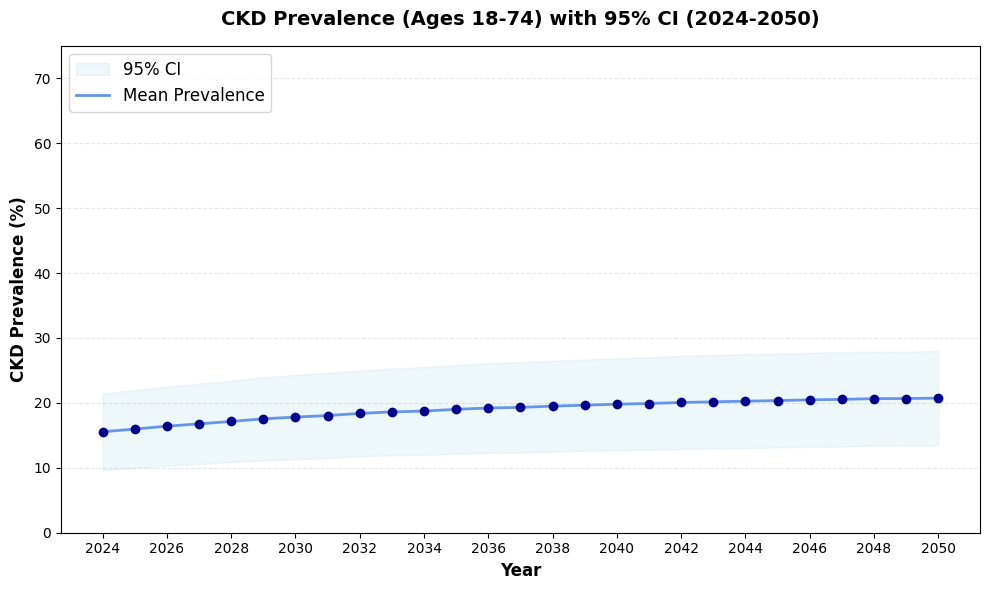

In [80]:
import matplotlib.pyplot as plt
# Set initial and final years
start_year = 2024  # Can be changed to 2000 or other year
end_year = 2050

# Create years array
years = np.arange(start_year, end_year + 1)
num_years = len(years)

# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot the confidence interval as a shaded region
plt.fill_between(years, prevalence_df['k0_prevalence'][-num_years:], 
                 prevalence_df['k1_prevalence'][-num_years:], 
                 alpha=0.2, color='lightblue', label='95% CI')

# Plot the mean line
mean_prevalence = (prevalence_df['k0_prevalence'][-num_years:] + 
                  prevalence_df['k1_prevalence'][-num_years:])/2
plt.plot(years, mean_prevalence, color='#6495ED', linewidth=2, label='Mean Prevalence')

# Add dots for mean prevalence values
plt.plot(years, mean_prevalence, 'o', color='darkblue', markersize=6)

# Add specific data points
# plt.plot([2019], [8.7], 'o', color='red', markersize=8, label='2020 Data Point')
# plt.plot([2022], [13.8], 'o', color='red', markersize=8, label='2022 Data Point')

# Customize the plot
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('CKD Prevalence (%)', fontsize=12, fontweight='bold')
plt.title(f'CKD Prevalence (Ages 18-74) with 95% CI ({start_year}-{end_year})',
         fontsize=14, fontweight='bold', pad=15)

# Add grid
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Customize ticks
plt.xticks(years[::2])  # Show every 2nd year
plt.tick_params(axis='both', labelsize=10)
plt.ylim(0,75)
# Add legend
plt.legend(loc='upper left', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

